***Population of Planetary Systems Generator***

1 or 2 planets allowed, with or without SNR filtering (to favor systems more likely to be detected by Gaia)


In [18]:
import pandas as pd
import os
import numpy as np
import astropy
import astropy.units as u
from astropy.constants import M_jup, M_earth
import astropy.units as u
import matplotlib.pyplot as plt
from planet_stability import near_first_order_resonance, classify_with_resonance

M_JUP_IN_MSUN = 9.5458e-4
def semimajor_axis_to_period(a_au, mstar_msun):
    """Kepler's third law: P [yr] from a [AU] and M_star [Msun]."""
    return np.sqrt(a_au**3 / mstar_msun)

def gen_orbits_csv(star_catalog_path, output_dir, output_file, filter_snr=False, n_planets=1,  max_retries=500, seed=42):
    '''
    Generates a CSV with 1 or 2 mock planets for real Gaia stars.
    Stability criterion for 2 planet systems must be met.

    Parameters:
    star_catalog_path : str
        Path to Gaia star catalog file.
    output_dir : str
        Directory for the output CSV. Created if it doesn't exist.
    output_file : str
        Filename for the output CSV.
    filter_snr : bool, optional
        If True, apply SNR-based rejection sampling. Default is False.
    n_planets : int, optional
        1 or 2. Default is 1.
    batch_size : int, optional
        Proposal pool size per iteration (only matters when rejection
        sampling is active). Default is 50000.


    Returns:
    csv_data : pandas.DataFrame
    '''
    M_mars_Mjup = (0.107 * M_earth).to(u.M_jup).value
    T_BASELINE = 24.75
    M_jup_per_Msun = M_jup.to(u.M_sun).value
    rng = np.random.default_rng(seed)
    os.makedirs(output_dir, exist_ok=True)

    catalog = pd.read_csv(star_catalog_path)
    n_stars = len(catalog)
    source_ids = catalog['gaia_source_id'].values
    mstar_arr = catalog['mass_interp'].values

    # SNR (only needed if filter_snr)
    if filter_snr:
        ms = mstar_arr
        sa = 10**rng.uniform(np.log10(1), np.log10(100), size=len(mstar_arr))
        ma = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80), size=len(mstar_arr))
        sc = (T_BASELINE**2 * ms)**(1/3)
        snr = (ma / ms) * sa / (1.0 + (sa /sc)**3)
        snr_max_global = snr.max()

    def _draw_one_planet(mstar, n=1):
        """Draw sma, mass for one planet (with optional SNR rejection)."""
        if filter_snr:
            sma_crit = (T_BASELINE**2 * mstar)**(1/3)
            while True:
                sma = 10**rng.uniform(np.log10(1), np.log10(100), size=n)
                mass = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80), size=n)
                snr_proxy = (mass / mstar) * sma / (1.0 + (sma / sma_crit)**3)
                accept = rng.uniform(size=n) < (snr_proxy / snr_max_global)
                if accept.any():
                    idx = np.where(accept)[0][0]
                    return sma[idx], mass[idx]
        else:
            sma = 10**rng.uniform(np.log10(1), np.log10(100))
            mass = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80))
            return sma, mass

    def _draw_angles(rng):
        ecc = rng.uniform(0, 0.99)
        inc = np.degrees(np.arccos(rng.uniform(-1, 1)))
        Omega = rng.uniform(0, 360)
        omega = rng.uniform(0, 360)
        M_anom = rng.uniform(0, 360)
        return ecc, inc, Omega, omega, M_anom

    rows = []
    n_failed = 0

    for i in range(n_stars):
        sid = source_ids[i]
        mstar = mstar_arr[i]

        if n_planets == 1:
            sma, mass_pl = _draw_one_planet(mstar)
            ecc, inc, Omega, omega, M_anom = _draw_angles(rng)
            rows.append({
                'gaia_source_id': sid, 'mass_st': mstar,
                'sma': sma, 'ecc': ecc, 'mass_pl': mass_pl,
                'inc': inc, 'Omega': Omega, 'omega': omega, 'M_anom': M_anom,
                'period': semimajor_axis_to_period(sma, mstar),
            })
        else:  # n_planets == 2
            found = False
            for attempt in range(max_retries):
                sma1, mass1 = _draw_one_planet(mstar)
                sma2, mass2 = _draw_one_planet(mstar)
                ecc1, inc1, Om1, om1, Ma1 = _draw_angles(rng)
                ecc2, inc2, Om2, om2, Ma2 = _draw_angles(rng)
                coplanar = bool(rng.integers(2))
                if coplanar:
                    inc2 = inc1
                    Om2 = Om1

                # enforce sma1 < sma2 so closer in
                if sma1 > sma2:
                    sma1, sma2 = sma2, sma1
                    mass1, mass2 = mass2, mass1
                    ecc1, ecc2 = ecc2, ecc1
                    inc1, inc2 = inc2, inc1
                    Om1, Om2 = Om2, Om1
                    om1, om2 = om2, om1
                    Ma1, Ma2 = Ma2, Ma1

                mu1 = mass1 * M_jup_per_Msun / mstar
                mu2 = mass2 * M_jup_per_Msun / mstar
                label = classify_with_resonance(mu1, mu2, sma1, sma2, ecc1, ecc2)
                if label not in ("unstable", "likely_unstable"):
                    found = True
                    break

            if not found:
                n_failed += 1
                continue  # skip this star

            P1 = semimajor_axis_to_period(sma1, mstar)
            P2 = semimajor_axis_to_period(sma2, mstar)
            rows.append({
                'gaia_source_id': sid, 'mass_st': mstar,
                'sma_1': sma1, 'ecc_1': ecc1, 'mass_pl_1': mass1,
                'inc_1': inc1, 'Omega_1': Om1, 'omega_1': om1, 'M_anom_1': Ma1,
                'sma_2': sma2, 'ecc_2': ecc2, 'mass_pl_2': mass2,
                'inc_2': inc2, 'Omega_2': Om2, 'omega_2': om2, 'M_anom_2': Ma2,
                'period_1': P1, 'period_2': P2,
                'P_ratio': P2 / P1,
                'near_2_1': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=1)[0],
                'near_3_2': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=2)[0], 'coplanar': coplanar,
            })

        if (i + 1) % 500 == 0 or i == n_stars - 1:
            print(f"  processed {i+1} / {n_stars} stars")

    if n_failed:
        print(f"  WARNING: {n_failed} stars skipped (stability not met in {max_retries} attempts)")

    csv_data = pd.DataFrame(rows)
    if n_planets == 2:
        csv_data['near_resonance'] = csv_data['near_2_1'] | csv_data['near_3_2']

    output_fpath = os.path.join(output_dir, output_file)
    print(f"Writing {len(csv_data)} systems to {output_fpath}")
    csv_data.to_csv(output_fpath, index=False)
    return csv_data

def plot_pop_diagnostics(ag_path, snr_path, output_path="pop_diagnostics.png", n_planets=2):
    if n_planets == 2:
        ag = pd.read_csv(ag_path)
        snr = pd.read_csv(snr_path)

        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        hist_kw = dict(bins=60, alpha=0.5, density=True)

        # SMA and stellar mass
        axes[0,0].hist(ag['sma_1'], label='agnostic', **hist_kw)
        axes[0,0].hist(snr['sma_1'], label='SNR-filt', **hist_kw)
        axes[0,0].set(xlabel='sma_1 [AU]', title='Inner SMA'); axes[0,0].legend()

        axes[0,1].hist(ag['sma_2'], label='agnostic', **hist_kw)
        axes[0,1].hist(snr['sma_2'], label='SNR-filt', **hist_kw)
        axes[0,1].set(xlabel='sma_2 [AU]', title='Outer SMA')

        axes[0,2].hist(ag['mass_st'], label='agnostic', **hist_kw)
        axes[0,2].hist(snr['mass_st'], label='SNR-filt', **hist_kw)
        axes[0,2].set(xlabel='M★ [M☉]', title='Stellar Mass')

        #planet masses and period ratio
        axes[1,0].hist(np.log10(ag['mass_pl_1']), label='agnostic', **hist_kw)
        axes[1,0].hist(np.log10(snr['mass_pl_1']), label='SNR-filt', **hist_kw)
        axes[1,0].set(xlabel='log₁₀(mass_pl_1) [Mjup]', title='Inner Planet Mass')

        axes[1,1].hist(np.log10(ag['mass_pl_2']), label='agnostic', **hist_kw)
        axes[1,1].hist(np.log10(snr['mass_pl_2']), label='SNR-filt', **hist_kw)
        axes[1,1].set(xlabel='log₁₀(mass_pl_2) [Mjup]', title='Outer Planet Mass')

        axes[1,2].hist(np.log10(ag['P_ratio']), label='agnostic', **hist_kw)
        axes[1,2].hist(np.log10(snr['P_ratio']), label='SNR-filt', **hist_kw)
        axes[1,2].set(xlabel='log₁₀(P₂/P₁)', title='Period Ratio')

        # eccentricities and inclination
        axes[2,0].hist(ag['ecc_1'], label='ecc_1', bins=50, alpha=0.4, density=True)
        axes[2,0].hist(ag['ecc_2'], label='ecc_2', bins=50, alpha=0.4, density=True)
        axes[2,0].axhline(1/0.99, ls='--', c='k', lw=0.8, label='U(0,0.99)')
        axes[2,0].set(xlabel='ecc', title='Agnostic: ecc₁ vs ecc₂'); axes[2,0].legend()

        axes[2,1].hist(snr['ecc_1'], label='ecc_1', bins=50, alpha=0.4, density=True)
        axes[2,1].hist(snr['ecc_2'], label='ecc_2', bins=50, alpha=0.4, density=True)
        axes[2,1].axhline(1/0.99, ls='--', c='k', lw=0.8, label='U(0,0.99)')
        axes[2,1].set(xlabel='ecc', title='SNR-filt: ecc₁ vs ecc₂'); axes[2,1].legend()

        cos_bins = np.linspace(-1, 1, 50)
        axes[2,2].hist(np.cos(np.radians(ag['inc_1'])), bins=cos_bins, alpha=0.5, label='agnostic', density=True)
        axes[2,2].hist(np.cos(np.radians(snr['inc_1'])), bins=cos_bins, alpha=0.5, label='SNR-filt', density=True)
        axes[2,2].axhline(0.5, ls='--', c='k', lw=0.8, label='isotropic')
        axes[2,2].set(xlabel='cos(inc₁)', title='Inclination Check'); axes[2,2].legend()

        fig.suptitle(f'Population Diagnostics  (N={len(ag)} each)', fontsize=14, y=1.01)
        fig.tight_layout()
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {output_path}")
        plt.close(fig)
    else:
        ag = pd.read_csv(ag_path)
        snr = pd.read_csv(snr_path)
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        hist_kw = dict(bins=60, alpha=0.5, density=True)

        # Row 0: SMA, stellar mass, planet mass
        axes[0,0].hist(ag['sma'], label='agnostic', **hist_kw)
        axes[0,0].hist(snr['sma'], label='SNR-filt', **hist_kw)
        axes[0,0].set(xlabel='sma [AU]', title='Semi-major Axis'); axes[0,0].legend()

        axes[0,1].hist(ag['mass_st'], label='agnostic', **hist_kw)
        axes[0,1].hist(snr['mass_st'], label='SNR-filt', **hist_kw)
        axes[0,1].set(xlabel='M★ [M☉]', title='Stellar Mass')

        axes[0,2].hist(np.log10(ag['mass_pl']), label='agnostic', **hist_kw)
        axes[0,2].hist(np.log10(snr['mass_pl']), label='SNR-filt', **hist_kw)
        axes[0,2].set(xlabel='log₁₀(mass_pl) [Mjup]', title='Planet Mass'); axes[0,2].legend()

        # Row 1: period, eccentricity, inclination
        axes[1,0].hist(np.log10(ag['period']), label='agnostic', **hist_kw)
        axes[1,0].hist(np.log10(snr['period']), label='SNR-filt', **hist_kw)
        axes[1,0].set(xlabel='log₁₀(P) [yr]', title='Period'); axes[1,0].legend()

        axes[1,1].hist(ag['ecc'], label='agnostic', bins=50, alpha=0.5, density=True)
        axes[1,1].hist(snr['ecc'], label='SNR-filt', bins=50, alpha=0.5, density=True)
        axes[1,1].axhline(1/0.99, ls='--', c='k', lw=0.8, label='U(0,0.99)')
        axes[1,1].set(xlabel='ecc', title='Eccentricity'); axes[1,1].legend()

        cos_bins = np.linspace(-1, 1, 50)
        axes[1,2].hist(np.cos(np.radians(ag['inc'])), bins=cos_bins, alpha=0.5, label='agnostic', density=True)
        axes[1,2].hist(np.cos(np.radians(snr['inc'])), bins=cos_bins, alpha=0.5, label='SNR-filt', density=True)
        axes[1,2].axhline(0.5, ls='--', c='k', lw=0.8, label='isotropic')
        axes[1,2].set(xlabel='cos(inc)', title='Inclination Check'); axes[1,2].legend()

        fig.suptitle(f'Population Diagnostics (1-planet, N={len(ag)} each)', fontsize=14, y=1.01)
        fig.tight_layout()
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {output_path}")
        plt.close(fig)
def orbit_getpoints_au(a, e, inc, Omega, omega, N=500):
    """Keplerian ellipse in AU based on Hilditch 2004"""
    w = np.radians(omega)
    Omega = np.radians(Omega)
    i = np.radians(inc)
    A = a * (np.cos(w) * np.cos(Omega) - np.sin(w) * np.sin(Omega) * np.cos(i))
    B = a * (np.cos(w) * np.sin(Omega) + np.sin(w) * np.cos(Omega) * np.cos(i))
    F = a * (-np.sin(w) * np.cos(Omega) - np.cos(w) * np.sin(Omega) * np.cos(i))
    G = a * (-np.sin(w) * np.sin(Omega) + np.cos(w) * np.cos(Omega) * np.cos(i))
    EA = np.linspace(0, 2 * np.pi, N)
    X = np.cos(EA) - e
    Y = np.sqrt(1 - e**2) * np.sin(EA)

    x = B * X + G * Y
    y = A * X + F * Y
    return x, y


**Test double planet case, no SNR filter**

  processed 500 / 10672 stars
  processed 1000 / 10672 stars
  processed 1500 / 10672 stars
  processed 2000 / 10672 stars
  processed 2500 / 10672 stars
  processed 3000 / 10672 stars
  processed 3500 / 10672 stars
  processed 4000 / 10672 stars
  processed 4500 / 10672 stars
  processed 5000 / 10672 stars
  processed 5500 / 10672 stars
  processed 6000 / 10672 stars
  processed 6500 / 10672 stars
  processed 7000 / 10672 stars
  processed 7500 / 10672 stars
  processed 8000 / 10672 stars
  processed 8500 / 10672 stars
  processed 9000 / 10672 stars
  processed 9500 / 10672 stars
  processed 10000 / 10672 stars
  processed 10500 / 10672 stars
  processed 10672 / 10672 stars
Writing 10672 systems to outputs/agnostic_pop_2planets.csv
33 / 10672 near resonance (0.3%)
  near 2:1: 19
  near 3:2: 14
          sma_1      sma_2   P_ratio  near_2_1  near_3_2
199    6.721146   8.912405  1.526959     False      True
468    2.423998   3.862328  2.011293      True     False
511    1.045840   1.361

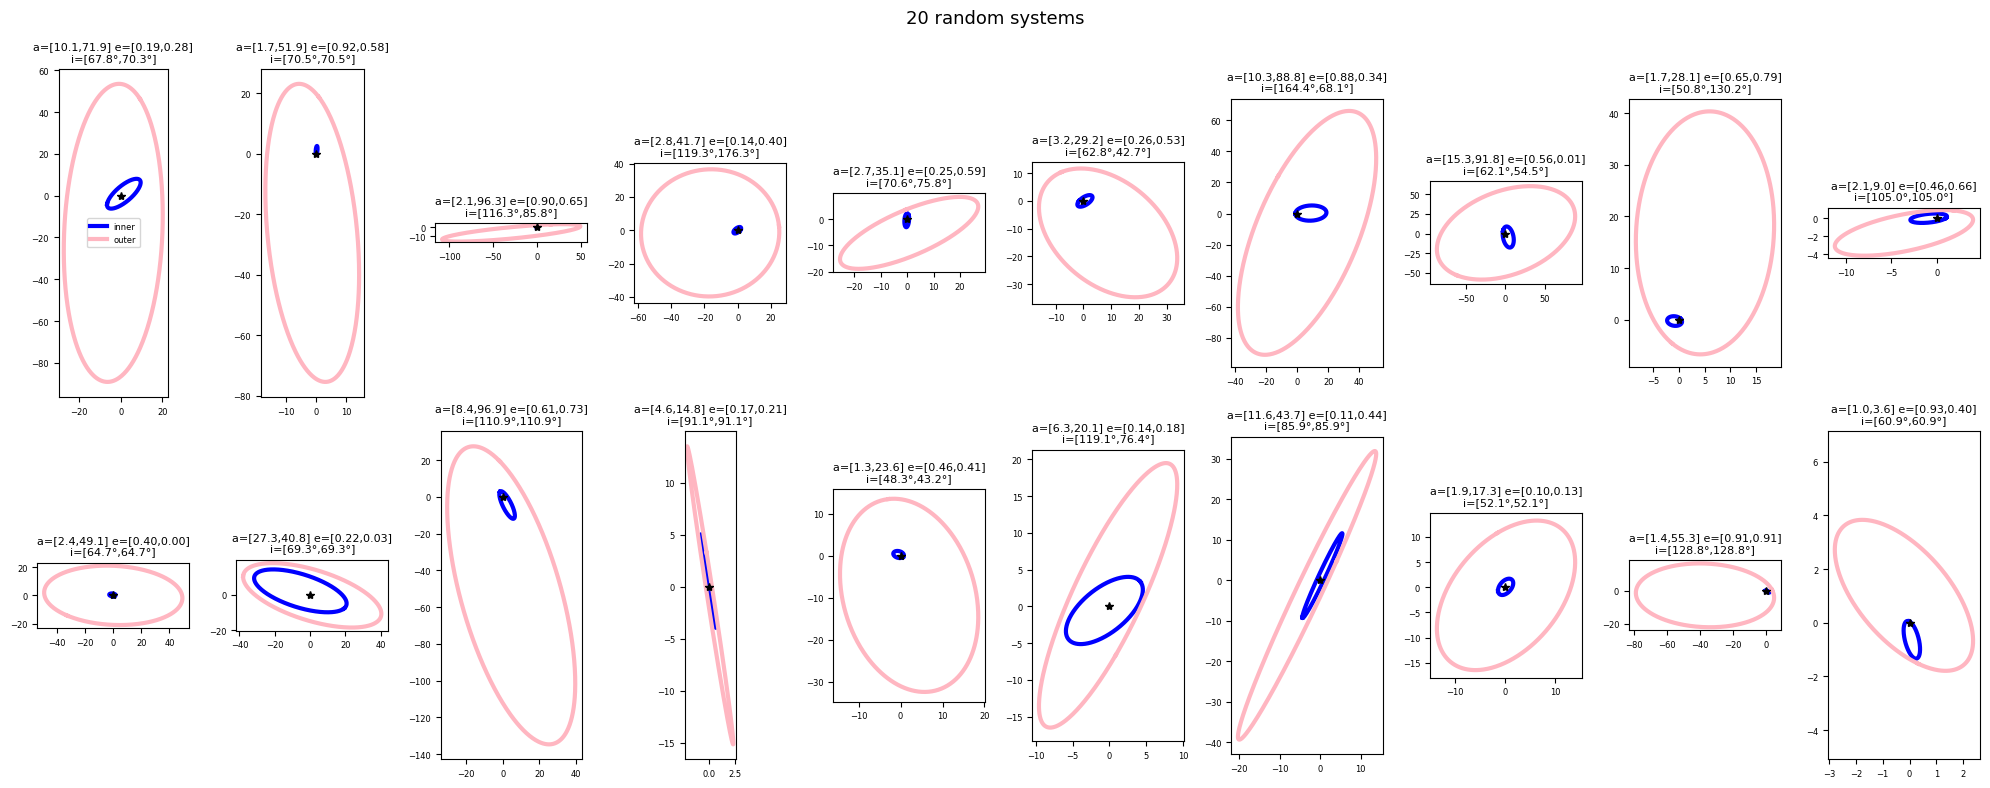

In [19]:

#create csv
output_dir_name = 'outputs/'
gen_orbits_csv("gaia_star_masses.csv", output_dir = output_dir_name, output_file = 'agnostic_pop_2planets.csv', filter_snr = False, n_planets=2)


#read it and plot some orbits :D
df = pd.read_csv("outputs/agnostic_pop_2planets.csv")
sample = df.sample(20, random_state=7).reset_index(drop=True)
df = pd.read_csv("outputs/agnostic_pop_2planets.csv")
res = df[df['near_resonance']]
print(f"{len(res)} / {len(df)} near resonance ({len(res)/len(df):.1%})")
print(f"  near 2:1: {df['near_2_1'].sum()}")
print(f"  near 3:2: {df['near_3_2'].sum()}")
print(res[['sma_1','sma_2','P_ratio','near_2_1','near_3_2']].head(10))
# sanity checking the orbits
fig, axes = plt.subplots(2, 10, figsize=(20, 8))

for idx, (_, row) in enumerate(sample.iterrows()):
    ax = axes.flat[idx]
    for tag, color, label in [("_1", "blue", "inner"), ("_2", "lightpink", "outer")]:
        x, y = orbit_getpoints_au(
            row[f"sma{tag}"], row[f"ecc{tag}"],
            row[f"inc{tag}"], row[f"Omega{tag}"], row[f"omega{tag}"],
        )
        ax.plot(x, y, lw=3, color=color, label=label)

    ax.plot(0, 0, "k*", ms=6)
    ax.set_aspect("equal")
    ax.set_title(
        f"a=[{row.sma_1:.1f},{row.sma_2:.1f}] "
        f"e=[{row.ecc_1:.2f},{row.ecc_2:.2f}]\n"
        f"i=[{row.inc_1:.1f}°,{row.inc_2:.1f}°]",
        fontsize=8,
    )
    ax.tick_params(labelsize=6)
    if idx == 0:
        ax.legend(fontsize=6)

fig.suptitle("20 random systems", fontsize=13)
plt.tight_layout()
plt.axis("equal")
plt.savefig("outputs/20systems.png", dpi=200)
plt.show()

**Test double planet case, with SNR filter**

  processed 500 / 10672 stars
  processed 1000 / 10672 stars
  processed 1500 / 10672 stars
  processed 2000 / 10672 stars
  processed 2500 / 10672 stars
  processed 3000 / 10672 stars
  processed 3500 / 10672 stars
  processed 4000 / 10672 stars
  processed 4500 / 10672 stars
  processed 5000 / 10672 stars
  processed 5500 / 10672 stars
  processed 6000 / 10672 stars
  processed 6500 / 10672 stars
  processed 7000 / 10672 stars
  processed 7500 / 10672 stars
  processed 8000 / 10672 stars
  processed 8500 / 10672 stars
  processed 9000 / 10672 stars
  processed 9500 / 10672 stars
  processed 10000 / 10672 stars
  processed 10500 / 10672 stars
  processed 10672 / 10672 stars
Writing 10672 systems to outputs/agnostic_pop_snr_filtered_2planets.csv
262 / 10672 near resonance (2.5%)
  near 2:1: 189
  near 3:2: 73
         sma_1      sma_2   P_ratio  near_2_1  near_3_2
5     3.094487   4.892493  1.987982      True     False
25    4.447641   7.031283  1.987729      True     False
76   18.690

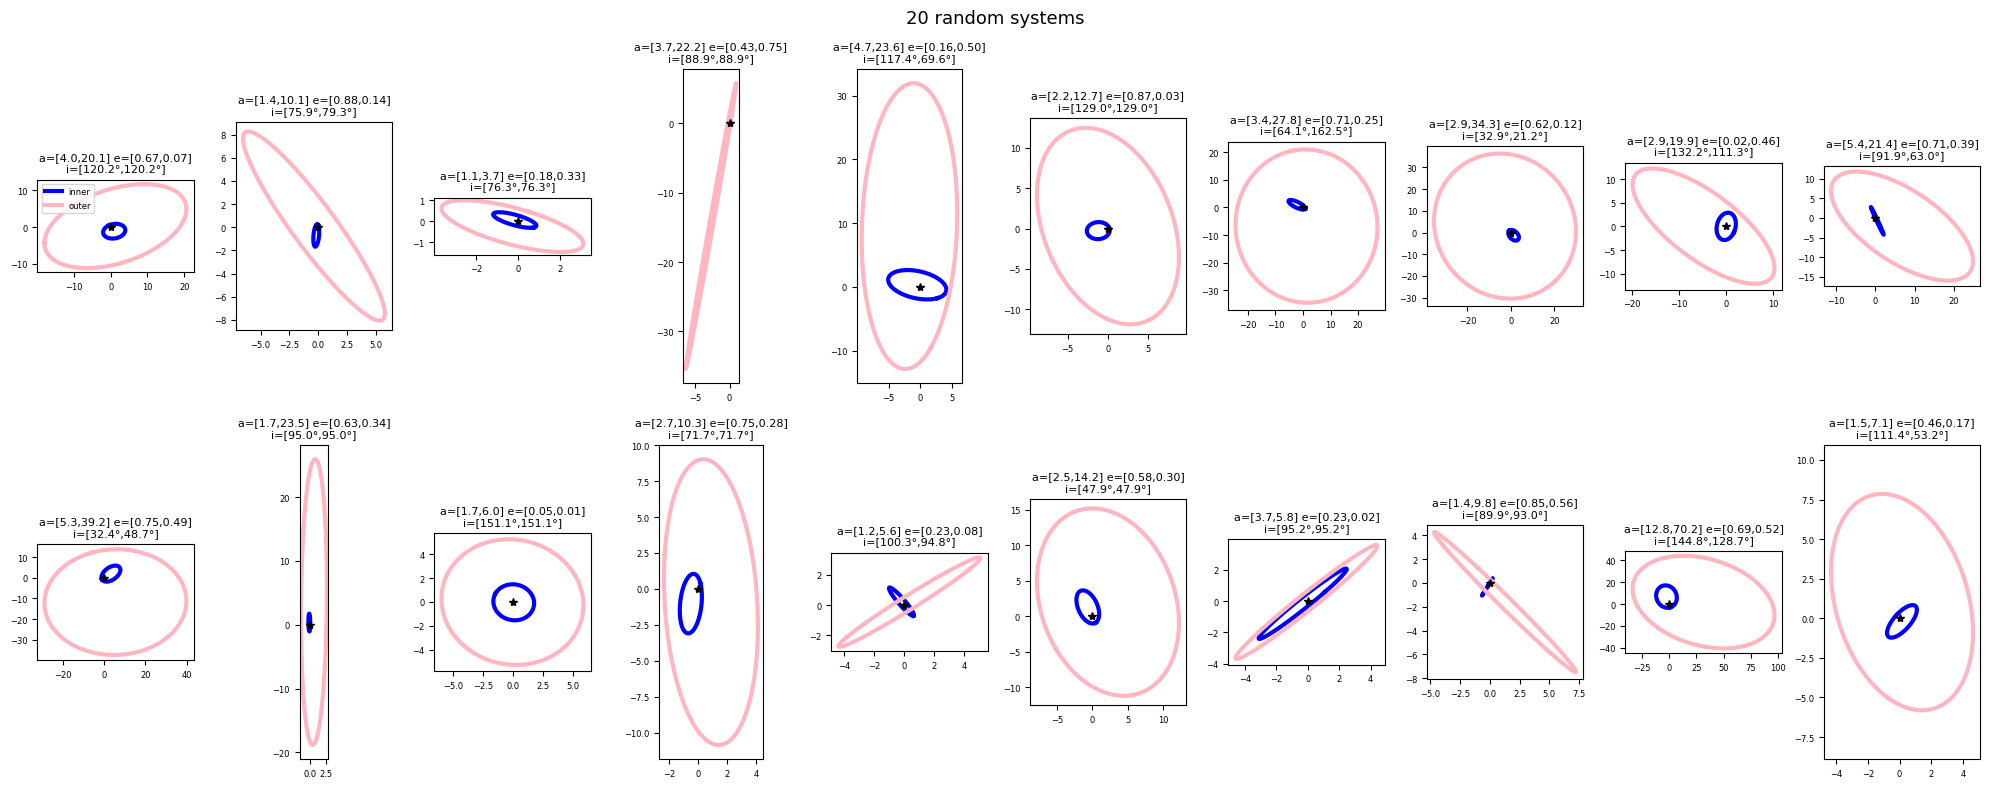

In [20]:
output_dir_name = 'outputs/'
gen_orbits_csv("gaia_star_masses.csv", output_dir = output_dir_name, output_file = 'agnostic_pop_snr_filtered_2planets.csv', filter_snr = True, n_planets=2)
def orbit_getpoints_au(a, e, inc, Omega, omega, N=500):
    """Keplerian ellipse in AU using Thiele-Innes constants"""
    w = np.radians(omega)
    Omega = np.radians(Omega)
    i = np.radians(inc)
    A = a * (np.cos(w) * np.cos(Omega) - np.sin(w) * np.sin(Omega) * np.cos(i))
    B = a * (np.cos(w) * np.sin(Omega) + np.sin(w) * np.cos(Omega) * np.cos(i))
    F = a * (-np.sin(w) * np.cos(Omega) - np.cos(w) * np.sin(Omega) * np.cos(i))
    G = a * (-np.sin(w) * np.sin(Omega) + np.cos(w) * np.cos(Omega) * np.cos(i))
    EA = np.linspace(0, 2 * np.pi, N)
    X = np.cos(EA) - e
    Y = np.sqrt(1 - e**2) * np.sin(EA)

    x = B * X + G * Y
    y = A * X + F * Y
    return x, y

df = pd.read_csv("outputs/agnostic_pop_snr_filtered_2planets.csv")
sample = df.sample(20, random_state=7).reset_index(drop=True)
res = df[df['near_resonance']]
print(f"{len(res)} / {len(df)} near resonance ({len(res)/len(df):.1%})")
print(f"  near 2:1: {df['near_2_1'].sum()}")
print(f"  near 3:2: {df['near_3_2'].sum()}")
print(res[['sma_1','sma_2','P_ratio','near_2_1','near_3_2']].head(10))
# sanity checking the orbits
fig, axes = plt.subplots(2, 10, figsize=(20, 8))

for idx, (_, row) in enumerate(sample.iterrows()):
    ax = axes.flat[idx]
    for tag, color, label in [("_1", "blue", "inner"), ("_2", "lightpink", "outer")]:
        x, y = orbit_getpoints_au(
            row[f"sma{tag}"], row[f"ecc{tag}"],
            row[f"inc{tag}"], row[f"Omega{tag}"], row[f"omega{tag}"],
        )
        ax.plot(x, y, lw=3, color=color, label=label)

    ax.plot(0, 0, "k*", ms=6)
    ax.set_aspect("equal")
    ax.set_title(
        f"a=[{row.sma_1:.1f},{row.sma_2:.1f}] "
        f"e=[{row.ecc_1:.2f},{row.ecc_2:.2f}]\n"
        f"i=[{row.inc_1:.1f}°,{row.inc_2:.1f}°]",
        fontsize=8,
    )
    ax.tick_params(labelsize=6)
    if idx == 0:
        ax.legend(fontsize=6)

fig.suptitle("20 random systems", fontsize=13)
plt.tight_layout()
plt.axis("equal")
plt.savefig("outputs/20systems.png", dpi=200)
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
ag_path = "outputs/agnostic_pop_2planets.csv"
snr_path ="outputs/agnostic_pop_snr_filtered_2planets.csv"
out_path ="outputs/pop_diagnostics_2planets.png"
plot_pop_diagnostics(ag_path, snr_path, out_path)

Saved to outputs/pop_diagnostics_2planets.png


In [22]:
# generate single planet case
output_dir_name = 'outputs/'
gen_orbits_csv("gaia_star_masses.csv", output_dir = output_dir_name, output_file = 'agnostic_pop_snr_filtered_1planet.csv', filter_snr = True, n_planets=1)
gen_orbits_csv("gaia_star_masses.csv", output_dir = output_dir_name, output_file = 'agnostic_pop_1planet.csv', filter_snr = False, n_planets=1)

ag_path="outputs/agnostic_pop_1planet.csv"
snr_path="outputs/agnostic_pop_snr_filtered_1planet.csv"
out_path="outputs/pop_diagnostics_1planet.png"
plot_pop_diagnostics(ag_path,snr_path,out_path,n_planets=1)


  processed 500 / 10672 stars
  processed 1000 / 10672 stars
  processed 1500 / 10672 stars
  processed 2000 / 10672 stars
  processed 2500 / 10672 stars
  processed 3000 / 10672 stars
  processed 3500 / 10672 stars
  processed 4000 / 10672 stars
  processed 4500 / 10672 stars
  processed 5000 / 10672 stars
  processed 5500 / 10672 stars
  processed 6000 / 10672 stars
  processed 6500 / 10672 stars
  processed 7000 / 10672 stars
  processed 7500 / 10672 stars
  processed 8000 / 10672 stars
  processed 8500 / 10672 stars
  processed 9000 / 10672 stars
  processed 9500 / 10672 stars
  processed 10000 / 10672 stars
  processed 10500 / 10672 stars
  processed 10672 / 10672 stars
Writing 10672 systems to outputs/agnostic_pop_snr_filtered_1planet.csv
  processed 500 / 10672 stars
  processed 1000 / 10672 stars
  processed 1500 / 10672 stars
  processed 2000 / 10672 stars
  processed 2500 / 10672 stars
  processed 3000 / 10672 stars
  processed 3500 / 10672 stars
  processed 4000 / 10672 star

In [24]:
df['coplanar'].value_counts()

coplanar
False    5358
True     5314
Name: count, dtype: int64